In [1]:
# Project 05: Moving Average Strategy Backtest

# Question:
# Does a 50-day moving average strategy outperform
# a buy-and-hold strategy over the last year?

In [2]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [3]:
apple = yf.download("AAPL",period='1y')

[*********************100%***********************]  1 of 1 completed


In [4]:
apple["MA50"] = apple["Close"].rolling(50).mean()
apple["Signal"] = apple["Close"]["AAPL"] > apple["MA50"]
apple["Returns"] = apple["Close"].pct_change()

In [5]:
apple["Strategy Returns"] = apple["Signal"] * apple["Returns"]
print(apple["Strategy Returns"])

Date
2025-06-23         NaN
2025-06-24   -0.000000
2025-06-25    0.000000
2025-06-26   -0.000000
2025-06-27    0.000000
                ...   
2026-06-15    0.018171
2026-06-16    0.009513
2026-06-17   -0.010994
2026-06-18    0.006961
2026-06-22    0.004815
Name: Strategy Returns, Length: 251, dtype: float64


In [6]:
print(apple["Strategy Returns"].cumprod())

Date
2025-06-23    NaN
2025-06-24   -0.0
2025-06-25   -0.0
2025-06-26    0.0
2025-06-27    0.0
             ... 
2026-06-15    0.0
2026-06-16    0.0
2026-06-17   -0.0
2026-06-18   -0.0
2026-06-22   -0.0
Name: Strategy Returns, Length: 251, dtype: float64


In [7]:
apple["Growth"] = 1 + apple["Strategy Returns"]
print(apple["Growth"])

Date
2025-06-23         NaN
2025-06-24    1.000000
2025-06-25    1.000000
2025-06-26    1.000000
2025-06-27    1.000000
                ...   
2026-06-15    1.018171
2026-06-16    1.009513
2026-06-17    0.989006
2026-06-18    1.006961
2026-06-22    1.004815
Name: Growth, Length: 251, dtype: float64


In [8]:
apple["MA50 Portfolio"] = apple["Growth"].cumprod()
print(apple["MA50 Portfolio"].tail())

Date
2026-06-15    1.479801
2026-06-16    1.493880
2026-06-17    1.477455
2026-06-18    1.487739
2026-06-22    1.494903
Name: MA50 Portfolio, dtype: float64


In [9]:
apple["Buy Hold Growth"] = 1 + apple["Returns"]
apple["Buy Hold Portfolio"] = apple["Buy Hold Growth"].cumprod()
print(apple["Buy Hold Portfolio"])

Date
2025-06-23         NaN
2025-06-24    0.994045
2025-06-25    1.000298
2025-06-26    0.997519
2025-06-27    0.997916
                ...   
2026-06-15    1.476903
2026-06-16    1.490954
2026-06-17    1.474561
2026-06-18    1.484825
2026-06-22    1.491975
Name: Buy Hold Portfolio, Length: 251, dtype: float64


In [10]:
print(apple["MA50 Portfolio"].tail(1))
print(apple["Buy Hold Portfolio"].tail(1))

Date
2026-06-22    1.494903
Name: MA50 Portfolio, dtype: float64
Date
2026-06-22    1.491975
Name: Buy Hold Portfolio, dtype: float64


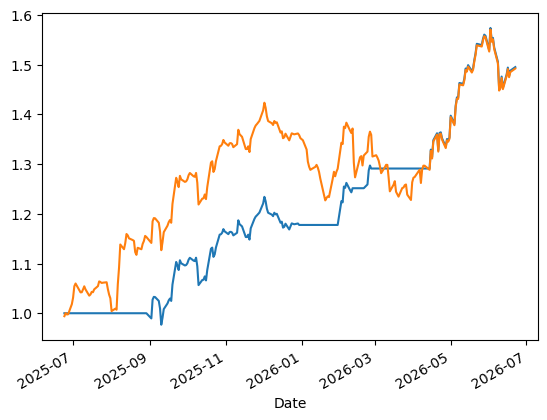

In [11]:
apple["MA50 Portfolio"].plot()
apple["Buy Hold Portfolio"].plot()
plt.show()

In [12]:
# Conclusion

# Moving  Average Strategy Return:
# 49.5% 

# Buy and Hold Return:
# 49.2%

# Moving Average strategy slightly outperformed
# Buy and Hold over this sample period.